In [15]:
import pandas as pd # 데이터 분석 및 조작을 위한 Pandas 라이브러리 불러오기 (중복 포함)
import pandas as pd # Pandas 라이브러리 불러오기 (중복 입력됨)
import matplotlib.pyplot as plt # 시각화/그래프 그리기를 위한 Matplotlib의 pyplot 모듈 불러오기
import seaborn as sns # Matplotlib 기반의 고급 통계 데이터 시각화 라이브러리 불러오기
import plotly.express as px # 인터랙티브(동적) 그래프를 쉽게 만들어주는 Plotly Express 불러오기
from kiwipiepy import Kiwi # 한국어 형태소 분석기인 Kiwi 클래스 불러오기

kiwi = Kiwi() # Kiwi 형태소 분석기 객체 생성 (텍스트 분석 준비)

plt.rcParams["font.family"] = "Malgun Gothic"   # Matplotlib 그래프에서 한글이 깨지지 않도록 기본 폰트를 '맑은 고딕'(윈도우 기본 한글 폰트)으로 설정
plt.rcParams["axes.unicode_minus"] = False     # Matplotlib 그래프의 축 눈금에서 음수 부호('-')가 깨지거나 네모로 출력되는 현상을 방지

In [16]:
def extract_nouns(text):
    # 입력된 텍스트(text)에서 2글자 이상의 명사만 추출하는 함수 정의
    
    nouns = []
    # 추출된 모든 명사를 임시로 저장할 빈 리스트 생성

    # 토크나이저 적용
    result = kiwi.tokenize(text)
    # Kiwi 형태소 분석기를 사용해 입력 텍스트를 형태소(토큰) 단위로 분리

    for token in result:
        # 분리된 형태소들을 하나씩 순회
        if token.tag.startswith("N"):  # N으로 시작하는 품사 = 명사 계열 (NNG: 일반명사, NNP: 고유명사, NP: 대명사 등)
            nouns.append(token.form)
            # 조건에 맞는 형태소의 단어 표형(form)을 nouns 리스트에 추가

    filtered_nouns = []
    # 한 글자 단어를 제외한 최종 명사들을 담을 빈 리스트 생성

    for noun in nouns:
        # 수집된 명사들을 하나씩 순회
        if len(noun) > 1:
            # 명사의 길이가 2글자 이상인 경우에만 조건 성립 (1글자 조사/무의미한 단어 제거)
            filtered_nouns.append(noun)
            # 조건(2글자 이상)을 만족하는 명사만 filtered_nouns 리스트에 추가

    return filtered_nouns
    # 최종 필터링된 명사 리스트를 함수의 결과값으로 반환

In [17]:
df = pd.read_csv("../data/11-1_visitjeju_reviews.csv")
# 상위 경로(..)의 data 폴더에 있는 '11-1_visitjeju_reviews.csv' 파일(제주 방문 리뷰 데이터)을 읽어와 Pandas 데이터프레임(df) 형태로 저장

df.head()
# 데이터프레임의 상위 5개 행(row)을 출력하여 데이터의 전반적인 구조, 컬럼명, 샘플 데이터를 확인

df[['리뷰내용']].head(3)
# 전체 데이터 중 '리뷰내용' 컬럼만 선택하여, 상위 3개 행만 추출하여 확인

,리뷰내용
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ..."
2,메밀꽃 지평선과 하늘입니다


In [18]:
all_nouns = []
# 전체 리뷰에서 추출된 명사들을 모아둘 빈 리스트 생성 (추후 단어 빈도 분석 등에 활용 가능)

df["리뷰내용"] = df["리뷰내용"].fillna("")
# '리뷰내용' 컬럼의 결측값(NaN/Null)을 빈 문자열("")로 대체하여, 형태소 분석 시 발생할 수 있는 에러 방지

df['리뷰내용_명사'] = df['리뷰내용'].apply(extract_nouns)
# '리뷰내용' 컬럼의 모든 텍스트를 순차적으로 extract_nouns 함수에 전달·실행하여, 추출된 명사 리스트를 '리뷰내용_명사' 컬럼에 일괄 저장

df[['리뷰내용','리뷰내용_명사']]
# 원본 '리뷰내용'과 추출된 '리뷰내용_명사' 컬럼 두 개를 선택하여 데이터프레임 형태로 함께 확인

,리뷰내용,리뷰내용_명사
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,"[제주특별자치도, 서귀포시, 안덕면, 병악로, 위치, 카멜리아힐동백, 언덕, 친구,..."
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...","[성이시돌목, 테쉬폰, 우유부단, 왕따, 나무, 이색, 볼거리, 초원, 나무, 가운..."
2,메밀꽃 지평선과 하늘입니다,"[메밀꽃, 지평선, 하늘]"
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,[]
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,[]
...,...,...
5912,제주를 사랑하시는 저의 아버지는 겨울왕국이 있을 것처럼 눈이 소복하게 쌓인 한라산을...,"[제주, 사랑, 아버지, 겨울, 왕국, 한라산, 등반, 지금, 사진, 제주, 애정,..."
5913,중문 놀러왔다가 들렸어요~ 체험 할 거리도 많고 사진도 많이 찍을 수 있어서 좋았어...,"[중문, 체험, 거리, 사진, 그램, 콘서트, 공연, 별도, 요금, 체험, 체험, ..."
5914,#이호테우#이호테우말등대제주도여행 마지막 날 이호테우에서 아쉬움을 달래본다.,"[마지막, 이호테우, 아쉬움]"
5915,홀로 여행을 떠나 새로운각오을 다지고 왔어요.,"[여행, 각오]"


In [22]:
for doc_noun in df['리뷰내용_명사']:
    # 리뷰별 명사 리스트(예: ['제주', '바다'])를 하나씩 순회
    
    all_nouns.extend(doc_noun)
    # 각 리스트의 대괄호를 풀어서 단어 개별 원소만 all_nouns 리스트 끝에 붙여 하나로 통합 (append와 달리 1차원 리스트로 합쳐짐)

print(len(all_nouns))
# 중첩 없이 하나로 통합된 전체 명사의 총 개수(단어 수) 출력

85486


In [23]:
from collections import Counter
# 파이썬 내장 모듈 collections에서 데이터의 개수를 세어주는 Counter 클래스를 불러옴

count_result = Counter(all_nouns)
# 전체 명사 리스트(all_nouns) 내 각 단어별 출현 빈도수(개수)를 계산하여 Counter 객체 생성

count_result.most_common(10)
# 가장 빈도수가 높은 상위 10개 단어와 그 출현 횟수를 (단어, 빈도수) 튜플 형태의 리스트로 반환

[('제주', 3794),
 ('여행', 2042),
 ('제주도', 2010),
 ('바다', 1074),
 ('사진', 1024),
 ('시간', 618),
 ('가족', 604),
 ('한라산', 544),
 ('방문', 540),
 ('겨울', 540)]

In [32]:
# 불용어 
# 의미없는 단어라고 생각할때 -> 그 단어를 삭제
stopwords = ['제주도','제주']

filtered_all_nouns = []

for noun in all_nouns:
    if noun not in stopwords:
        filtered_all_nouns.append(noun)


In [33]:
count_after = Counter(filtered_all_nouns)
count_after.most_common(20)

[('여행', 2042),
 ('바다', 1074),
 ('사진', 1024),
 ('시간', 618),
 ('가족', 604),
 ('한라산', 544),
 ('방문', 540),
 ('겨울', 540),
 ('추천', 510),
 ('풍경', 506),
 ('힐링', 484),
 ('추억', 480),
 ('친구', 474),
 ('생각', 472),
 ('마음', 468),
 ('자연', 464),
 ('아이', 444),
 ('우도', 406),
 ('사람', 404),
 ('카페', 388)]

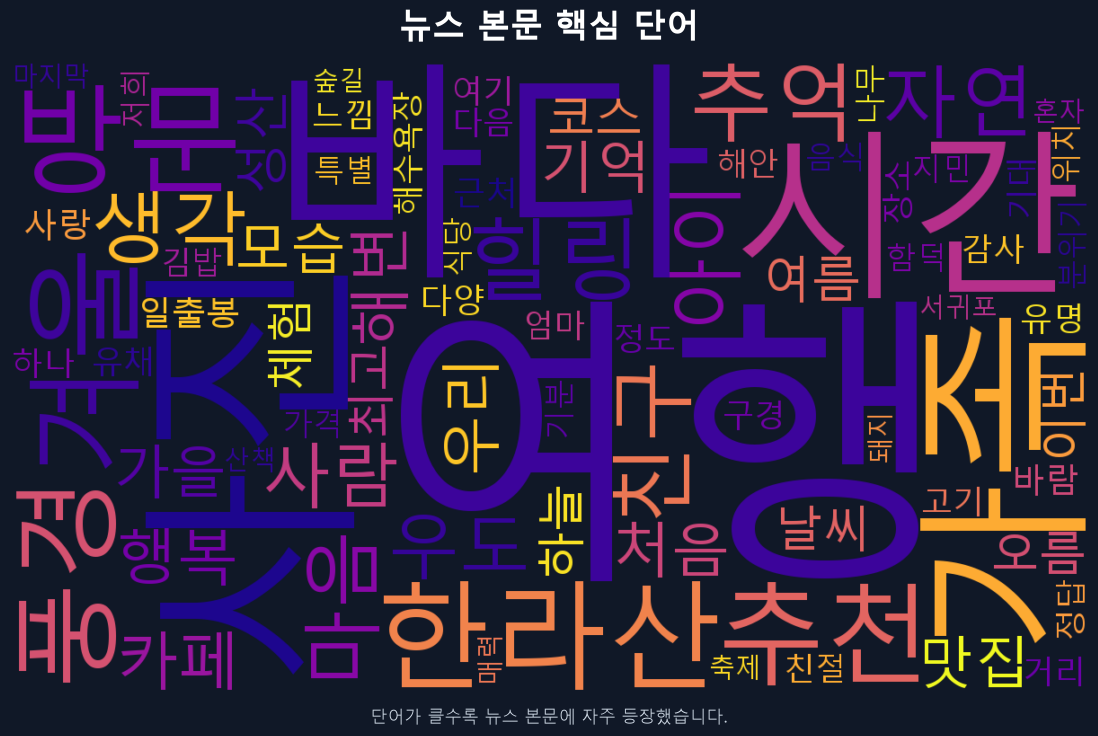

In [34]:
# 시각화 - 워드클라우드: 자주 나온 단어일수록 크게 표시합니다.
from wordcloud import WordCloud

# font_path를 지정하면 워드클라우드에서도 한글이 깨지지 않습니다.
font_path = r"C:\Windows\Fonts\malgun.ttf"

# 너무 적게 나온 단어는 제외하여 핵심 단어가 더 잘 보이게 합니다.
wordcloud = WordCloud(
    font_path=font_path,
    width=1200,
    height=700,
    background_color="#101827",  # 차분한 남색 배경
    colormap="plasma",             # 보라·주황·노랑 계열 색상
    max_words=80,                      # 표시할 단어의 최대 개수
    min_font_size=12,
    prefer_horizontal=0.85,            # 대부분의 단어를 가로로 배치
    contour_width=1,
    contour_color="#38bdf8",
    random_state=42                    # 다시 실행해도 같은 배치가 나오도록 설정
).generate_from_frequencies(count_after)

# 그림 전체 배경과 제목을 워드클라우드 색상에 맞춥니다.
plt.figure(figsize=(14, 8), facecolor="#101827")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # 그림 주변의 눈금과 테두리를 숨깁니다.
plt.title(
    "뉴스 본문 핵심 단어",
    fontsize=24,
    fontweight="bold",
    color="white",
    pad=18
)
plt.figtext(
    0.5, 0.04,
    "단어가 클수록 뉴스 본문에 자주 등장했습니다.",
    ha="center", fontsize=12, color="#cbd5e1"
)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()
